In [245]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import anndata
from glob import glob
import os
import scanpy as sc
import logging
import warnings
warnings.filterwarnings('ignore')

# Spatial transcriptomics

## process and filter region specific data

In [402]:
# Directory where original h5ad files are stored
data_dir = "/Users/caom/Downloads/All_Pucks_h5ad"

# File to store the list of processed filenames
checkpoint_file_path = "/Users/caom/Downloads/processed_filenames.txt"

# Create the checkpoint file if it does not exist
if not os.path.exists(checkpoint_file_path):
    with open(checkpoint_file_path, 'w') as f:
        pass  # Just create the file if it doesn't exist


In [403]:

def load_processed_filenames(checkpoint_path):
    with open(checkpoint_path, 'r') as file:
        processed_filenames = {line.strip() for line in file}
    return processed_filenames



In [555]:
processed_filenames = load_processed_filenames(checkpoint_file_path)
brain_list = ['MPO', 'MPN', 'PS', 'PD', 'ADP']
filtered_datasets = []

for filename in os.listdir(data_dir):
    if filename.endswith('.h5ad') and filename not in processed_filenames:
        file_path = os.path.join(data_dir, filename)
        adata = sc.read_h5ad(file_path)
        try:
            # Filter the data
            filtered_adata = adata[adata.obs['CCF_acronym'].isin(brain_list)]
            print(adata.obs['CCF_acronym'].unique())
        except Exception as e:
            logging.error(f"Error processing {filename}: {e}")
            with open(checkpoint_file_path, 'a') as f:
                f.write(filename + '\n')
            continue
            
        # Optionally process data and perform operations
        # Here we just check if there's any relevant data
        if filtered_adata.n_obs > 0:
            filtered_datasets.append(filtered_adata)
            # Update the checkpoint file with the filename
            
        print(f"Processed {filename}")
        with open(checkpoint_file_path, 'a') as f:
                f.write(filename + '\n')



['ICd' 'PRNr' 'PAG' 'ENTm2' 'CUN' 'scp' 'CS' 'MRN' 'MB' 'DR' 'ICc' 'TRN'
 'PPN' 'ICe' 'SCdg' 'SCdw' 'P' 'ml' 'POR' 'tspc' 'PSV' 'll' 'VTN' 'NLL'
 'cic' 'sctv' 'VISpl1' 'PB' 'NA' 'rust' 'mcp' 'sV' 'SUT' 'NTB' 'PC5'
 'ENTm1' 'mlf' 'AT' 'P5' 'AQ' 'PAR' 'py' 'CB' 'cst' 'SIM' 'MY' 'IVn' 'moV'
 'tb' 'root' 'bic' 'FL' 'CUL4, 5' 'VISp1' 'VISpl2/3' 'VISpor1']
Processed Puck_Num_75.h5ad
['ACB' 'ACAv2/3' 'NA' 'OT' 'MOs2/3' 'CP' 'SSp-m6a' 'SSp-m5' 'PIR' 'GU5'
 'MOp2/3' 'GU4' 'lot' 'MOs5' 'AId1' 'VL' 'STR' 'SSp-m4' 'MOp6a' 'AIv2/3'
 'MOp5' 'SSp-ul5' 'CLA' 'SH' 'SSp-m2/3' 'AId5' 'ccg' 'GU6a' 'AId6a' 'AIv5'
 'SSs4' 'MOs6a' 'SI' 'SSp-ul4' 'SEZ' 'SSp-m6b' 'LSr' 'ACAd6a' 'GU2/3'
 'AIv1' 'EPd' 'OLF' 'AIv6a' 'AId2/3' 'ACAv6a' 'SSp-ul2/3' 'SSs2/3' 'IG'
 'ACAv5' 'ACAd2/3' 'SSs1' 'SSp-m1' 'ACAd5' 'ACAd1' 'scwm' 'SSp-ul1'
 'SSp-ul6a' 'MOp1' 'MOp6b' 'AId6b' 'cing' 'NDB' 'MOs6b' 'fa' 'aco' 'ACAv1'
 'GU1' 'ccb' 'ec' 'MOs1' 'ACAd6b' 'CTXsp' 'GU6b' 'ACAv6b' 'root']
Processed Puck_Num_22.h5ad
['NA' 'CP' 'fx' 'SSp-n

ERROR:root:Error processing Puck_Num_Unused_Posterior__108.h5ad: 'CCF_acronym'


['BLAp' 'BMAp' 'NA' 'PIR' 'PPT' 'PH' 'CA3' 'SPFm' 'DG-sg' 'CA1' 'AUDv5'
 'TEa6a' 'HY' 'root' 'ECT5' 'LGd-co' 'ENTl1' 'dhc' 'NPC' 'VISal2/3' 'LP'
 'RSPv1' 'VISal1' 'AUDp6a' 'TMv' 'LGv' 'PERI1' 'RSPv2/3' 'COApm' 'EPv'
 'PSTN' 'VISpm6a' 'AUDv6a' 'LA' 'VISp5' 'AUDpo6a' 'MRN' 'NOT' 'ENTl2'
 'HPF' 'PMv' 'RSPv5' 'VISpm4' 'VISal6a' 'PA' 'AUDv2/3' 'AUDv1' 'RSPd1'
 'PERI2/3' 'SUB' 'MB' 'PoT' 'PAG' 'COApl' 'ECT2/3' 'RPF' 'PMd' 'TEa1'
 'fiber tracts' 'fp' 'RSPagl1' 'MGv' 'VL' 'alv' 'AUDp4' 'RSPd2/3' 'fx'
 'or' 'MGm' 'VISpm5' 'VISp6a' 'TH' 'APN' 'CA2' 'ZI' 'DG-mo' 'IntG'
 'RSPagl6a' 'VISp2/3' 'LHA' 'DG-po' 'PAA' 'AUDpo2/3' 'TEa5' 'bsc' 'EPd'
 'cing' 'ec' 'FF' 'AUDp6b' 'ar' 'TMd' 'V3' 'RSPv6a' 'AUDp5' 'VISp4' 'SGN'
 'AUDp1' 'AUDpo5' 'OP' 'VISal4' 'AUDpo4' 'ENTl3' 'VISp1' 'VISrl6a'
 'TEa2/3' 'PVp' 'AUDp2/3' 'ECT6b' 'ME' 'RSPagl5' 'TEa4' 'VISpm1'
 'VISrl2/3' 'VISpm6b' 'st' 'VISal5' 'ml' 'VISpm2/3' 'SPFp' 'ENTl5'
 'VISrl5' 'RSPd5' 'ECT6a' 'CTXsp' 'VISp6b' 'MGd' 'Eth' 'RSPd6a' 'SUM'
 'POL' 'AUDv4' 'fr' 

ERROR:root:Error processing Puck_Num_Unused_Posterior__103.h5ad: 'CCF_acronym'


['CUL4, 5' 'NA' 'py' 'CENT3' 'CB' 'arb' 'IRN' 'LING' 'MV' 'GRN' 'tspc'
 'PFL' 'VII' 'PARN' 'SPVO' 'MY' 'PGRNd' 'V4' 'mlf' 'ANcr1' 'ANcr2' 'ml'
 'MARN' 'SIM' 'V4r' 'DCO' 'VeCB' 'PRP' 'VCO' 'RM' 'cbc' 'SUV' 'PPY' 'LAV'
 'RPA' 'COPY' 'IP' 'VIIn' 'scp' 'CENT2' 'PRM' 'sptV' 'DN' 'PGRNl' 'FN'
 'rust' 'sctv' 'icp' 'chpl' 'das' 'DEC' 'y' 'NTS' 'ICB' 'SPIV' 'ISN'
 'root']
Processed Puck_Num_87.h5ad
['PRNr' 'NA' 'PERI1' 'ENTm6' 'ENTl3' 'VISpor6a' 'SUB' 'HPF' 'POST'
 'VISpor1' 'PG' 'MRN' 'VISp6a' 'HATA' 'SNr' 'ENTl6a' 'VISl4' 'VISpl6a'
 'bic' 'VISpor4' 'RR' 'ENTl2' 'ENTl5' 'MB' 'mcp' 'PRE' 'PAG' 'VISpor5'
 'CB' 'DG-mo' 'VISpor2/3' 'VISp2/3' 'cst' 'root' 'moV' 'SCdg' 'll' 'ENTl1'
 'PBG' 'VISpl5' 'SCop' 'SCiw' 'RSPagl1' 'alv' 'VISp4' 'ECT1' 'SCig'
 'ENTm5' 'III' 'P' 'RSPagl5' 'VISpl6b' 'ICe' 'PERI2/3' 'rust' 'VISp5'
 'ENTm2' 'SCsg' 'ec' 'ENTm1' 'VISp1' 'CLI' 'sV' 'RSPd2/3' 'RSPagl2/3'
 'PAR' 'IPDL' 'SCdw' 'Su3' 'ENTm3' 'cpd' 'RSPagl6a' 'tspc' 'VISli1' 'RN'
 'VISl5' 'APr' 'VISl2/3' 'RSPd5' 'IPI' 'ml

ERROR:root:Error processing Puck_Num_Unused_Posterior__102.h5ad: 'CCF_acronym'


['MOB' 'PL5' 'MOs2/3' 'AON' 'ORBm2/3' 'ORBvl2/3' 'ORBvl5' 'MOs1' 'MOp1'
 'ORBvl1' 'MOp2/3' 'ORBl5' 'ORBl2/3' 'MOs5' 'ACAd5' 'ACAd2/3' 'ORBm5' 'NA'
 'ORBm6a' 'PL2/3' 'ORBvl6a' 'ORBm1' 'aco' 'PL1' 'AId5' 'lot' 'ORBl1'
 'MOs6a' 'FRP6a' 'ORBl6a' 'AIv2/3' 'PL6a' 'AId6a' 'AId2/3' 'ACAd1' 'AIv1'
 'OLF' 'MOp5' 'AId1' 'AIv5' 'ACAd6a' 'onl']
Processed Puck_Num_08.h5ad
['PRNr' 'DR' 'TRN' 'SCdg' 'NLL' 'MRN' 'ICd' 'scp' 'PPN' 'P' 'NA' 'ENTm3'
 'ENTm2' 'CUN' 'ICe' 'ml' 'SCiw' 'cst' 'CS' 'ENTm5' 'PAG' 'mcp' 'SCdw'
 'tspc' 'MB' 'SCig' 'Pa4' 'VISpl5' 'll' 'VISpl2/3' 'IV' 'SCop' 'VISp1'
 'PG' 'moV' 'ICc' 'bic' 'VISpor2/3' 'PAR' 'mlf' 'ENTm1' 'rust' 'dscp'
 'SCsg' 'AT' 'SCzo' 'RSPagl2/3' 'VISp4' 'VISpl1' 'VISpl4' 'RSPd2/3'
 'VISp2/3' 'ENTl2' 'mtg' 'IVn' 'RSPagl1' 'VISpor1' 'RSPd1' 'root' 'AQ'
 'APr' 'sV' 'ENTl3' 'CB' 'ENTl1']
Processed Puck_Num_73.h5ad
['NA' 'MOp5' 'MOs5' 'ACAv5' 'MOp6a' 'OLF' 'MOp2/3' 'SEZ' 'CP' 'LSr' 'ACB'
 'OT' 'AId5' 'SSs5' 'cing' 'NDB' 'ACAd5' 'PIR' 'ACAd6a' 'SSp-m5' 'ACAv2/3'
 'ccb

In [586]:
for filtered_adata in filtered_datasets:
    # original_raw = filtered_adata.raw.copy() if filtered_adata.raw else None

    # # Recreate the raw attribute to reflect the updated var_names
    # filtered_adata.raw = filtered_adata.copy()
    filtered_adata.var_names = filtered_adata.var['features']
    

In [589]:
if filtered_datasets:
    all_filtered_data = sc.concat(filtered_datasets, join='outer')
    # all_filtered_data = anndata.concat(filtered_datasets, join='outer')
    logging.info("Concatenated data shape: " + str(all_filtered_data.shape))
    # Save the concatenated data to a file
    all_filtered_data.write_h5ad('/Users/caom/Downloads/final_concatenated_data.h5ad')
else:
    logging.info("No data found with the specified CCF_acronyms.")


## plot summary statistics

In [591]:
data = all_filtered_data


In [630]:
def filter_neurons(data, gene_name='Rbfox3', threshold=0.0):
    # Step 1: Check if the gene is in the dataset
    if gene_name not in data.var_names:
        raise ValueError(f"{gene_name} not found in the variable names of the dataset.")
    
    # Step 2: Get the index of the gene in var_names
    neuron_idx = data.var_names.get_loc(gene_name)
    
    # Step 3: Create a mask for cells with expression greater than zero
    # Check if the data is stored as a dense or sparse array
    if isinstance(data.X, np.ndarray):
        expressions = data.X[:, neuron_idx]
    else:
        # If the data is stored in a sparse format, convert to dense array to perform the operation
        expressions = data.X[:, neuron_idx].toarray().flatten()

    mask = expressions > 0
    
    # Step 4: Filter the AnnData object to keep only cells with expression > 0
    neuron_data = data[mask]

    return neuron_data


def filter_by_ccf_acronym(data, acronyms):
    # Check if 'CCF_acronym' is in the observation DataFrame
    if 'CCF_acronym' not in data.obs.columns:
        raise ValueError("CCF_acronym is not a column in the .obs DataFrame.")

    # Filter data based on the acronym
    filtered_data = data[data.obs['CCF_acronym'].isin(acronyms)]

    return filtered_data


def filter_by_UMI(data, threshold = 500):
    # Check if 'n_counts' is in the observation DataFrame
    if 'nCount_Spatial' not in data.obs.columns:
        raise ValueError("n_counts is not a column in the .obs DataFrame.")

    # Filter data based on the threshold
    filtered_data = data[data.obs['nCount_Spatial'] > threshold]

    return filtered_data


# neuron_data = filter_neurons(data, 'Rbfox3')
# neuron_data = filter_neurons(data, 'Rbfox3', threshold=0.0)
# neuron_data = filter_neurons(neuron_data, 'Gad1', threshold=0.0)
neuron_data = filter_by_ccf_acronym(data, ['MPO', 'MPN', 'ADP', 'PS', 'PD'])
# neuron_data = filter_by_UMI(data, 500)

In [631]:
neuron_data.obs.shape

(19042, 25)

In [632]:
print(neuron_data.obs['CCF_acronym'].unique())
# genes_of_interest = ['Npy1r', 'Npy2r', 'Npy4r', 'Npy5r']

['ADP', 'PS', 'MPO', 'MPN']
Categories (4, object): ['ADP', 'MPN', 'MPO', 'PS']


In [633]:

def plot_gene_expression(adata, genes_of_interest):
    # Prepare a DataFrame to hold gene expressions with cells filtered by gene
    # Initialize an empty DataFrame
    plot_data = pd.DataFrame()

    for gene in genes_of_interest:
        if gene in adata.var_names:
            # Check if the data is sparse and convert to a dense array if true
            gene_index = adata.var_names.get_loc(gene)
            if isinstance(adata.X, np.ndarray):
                expressions = adata.X[:, gene_index]
            else:
                expressions = adata.X[:, gene_index].toarray().flatten()
            
            # Filter expressions greater than zero
            filtered_expressions = expressions[expressions > 0]
            if filtered_expressions.size > 0:
                # Prepare DataFrame for seaborn
                gene_df = pd.DataFrame({
                    'Expression': filtered_expressions,
                    'Gene': gene
                })
            else:
                # Include the gene with a NaN entry or placeholder if no cells have expression > 0
                gene_df = pd.DataFrame({
                    'Expression': [float('nan')],  # Use NaN or another placeholder
                    'Gene': gene
                })
        else:
            print(f"Gene {gene} not found in the dataset")
        
        plot_data = pd.concat([plot_data, gene_df], ignore_index=True)
    
    # Plotting using seaborn
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Gene', y='Expression', data=plot_data, palette='Reds')
    plt.title('Expression Levels of Genes of Interest')
    sns.despine()
    plt.show()




def plot_percentage_expressed(adata, genes_of_interest):
    # Create a dataframe to hold the results
    percentage = pd.DataFrame(index=genes_of_interest, columns=['Percentage'])

    # Loop through each gene and calculate the percentage
    for gene in genes_of_interest:
        # Extract the subset for the gene
        subset = adata[:, adata.var_names.isin([gene])]

        
        # Check if data is sparse and convert to dense if true
        if isinstance(subset.X, np.ndarray):
            more_than = subset.X > 0
        else:
            more_than = subset.X.toarray() > 0  # Ensure compatibility with sparse formats
            # more_than = subset.X > 0

        # Calculate percentage

        percent = np.sum(more_than) / subset.n_obs * 100
        percentage.loc[gene, 'Percentage'] = percent

    print(percentage)

    # Plotting
    fig, ax = plt.subplots(figsize=(4, 5))
    sns.barplot(data=percentage.reset_index(), x='index', y='Percentage', ax=ax, palette='Reds')
    sns.despine()
    plt.show()



def calculate_coexpression(adata, genes_of_interest, hormone_genes, threshold=0):
    # Initialize a DataFrame to store the results
    results = pd.DataFrame(columns=['Gene', 'Coexpression_With_Hormone_Genes (%)'])

    # Create masks for hormone genes expressions
    hormone_mask = adata[:, adata.var_names.isin(hormone_genes)].X > threshold
    if isinstance(hormone_mask, np.ndarray):
        hormone_cells = hormone_mask.any(axis=1)
    else:
        hormone_cells = hormone_mask.toarray().any(axis=1)

    # Iterate through each gene of interest
    for gene in genes_of_interest:
        if gene in adata.var_names:
            # Create a mask for the current gene expression
            gene_mask = adata[:, adata.var_names == gene].X > threshold
            if isinstance(gene_mask, np.ndarray):
                gene_cells = gene_mask.flatten()
            else:
                gene_cells = gene_mask.toarray().flatten()

            # Calculate co-expression
            coexpressed_cells = gene_cells & hormone_cells
            coexpression_percentage = np.sum(coexpressed_cells) / np.sum(gene_cells) * 100 if np.sum(gene_cells) > 0 else 0

            # Append results
            results = pd.concat([results, pd.DataFrame({
                'Gene': [gene],
                'Coexpression_With_Hormone_Genes (%)': [coexpression_percentage]
            })], ignore_index=True)
         
        else:
            # Handle case where gene is not found in the dataset
            print(f"Gene {gene} not found in the dataset")
    

    # plot the results
    fig, ax = plt.subplots(figsize=(4, 5))
    sns.barplot(data=results, x='Gene', y='Coexpression_With_Hormone_Genes (%)', ax=ax, palette='Reds')
    sns.despine()
    plt.show()

    return results



   



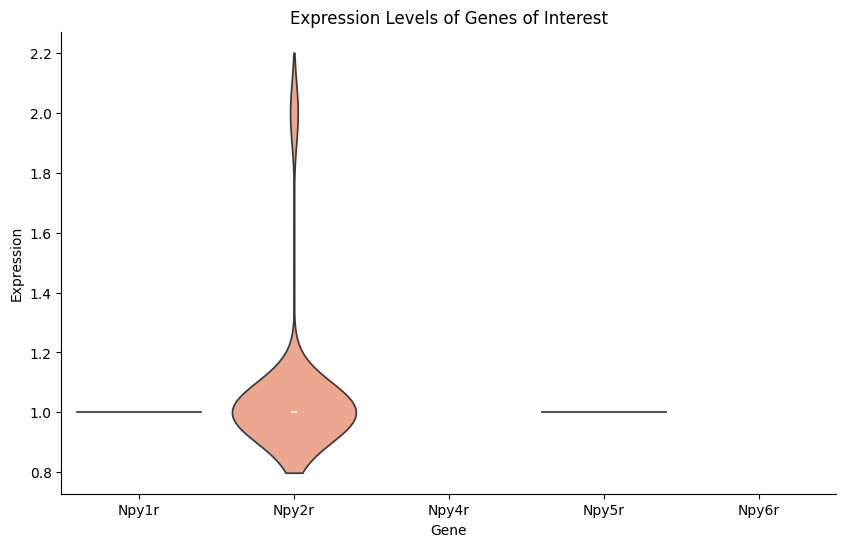

      Percentage
Npy1r   0.152295
Npy2r   0.362357
Npy4r        0.0
Npy5r   0.073522
Npy6r        0.0


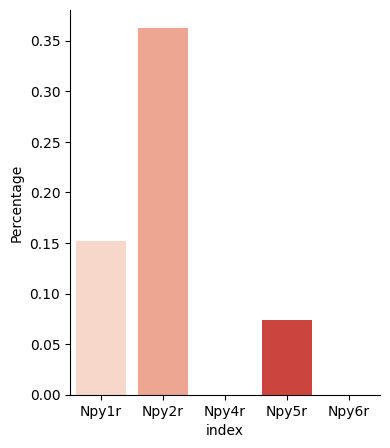

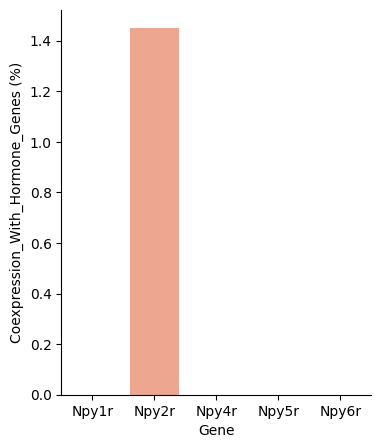

In [634]:
genes_of_interest = ['Npy1r', 'Npy2r', 'Npy4r', 'Npy5r', 'Npy6r']
hormone_genes = ['Esr1', 'Pgr']

non_zero = plot_gene_expression(neuron_data, genes_of_interest)
plot_percentage_expressed(neuron_data, genes_of_interest)
coexpression = calculate_coexpression(neuron_data, genes_of_interest, hormone_genes)


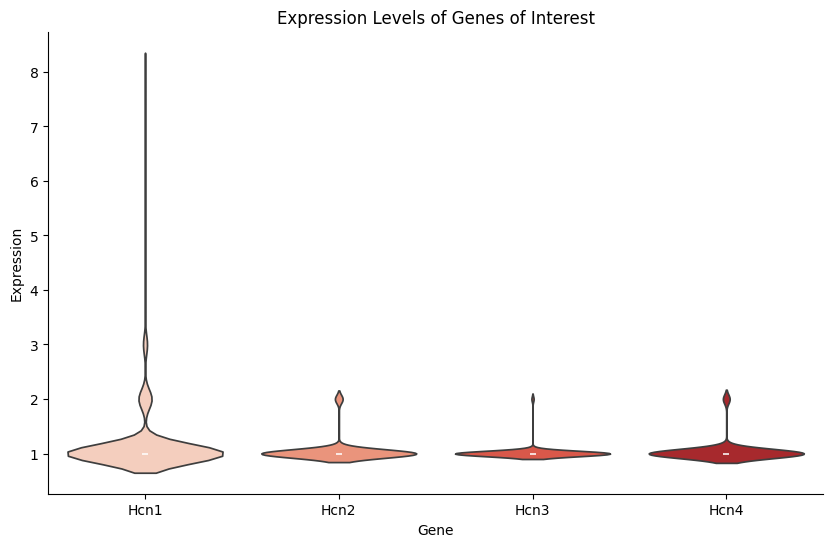

     Percentage
Hcn1   1.612226
Hcn2   0.777229
Hcn3   0.378112
Hcn4   0.378112


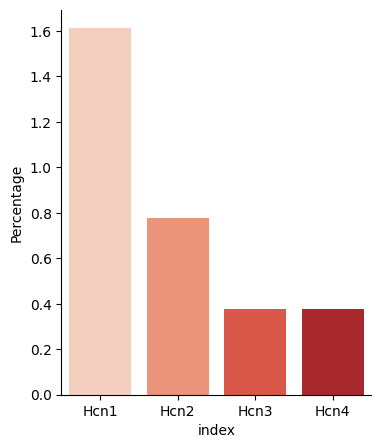

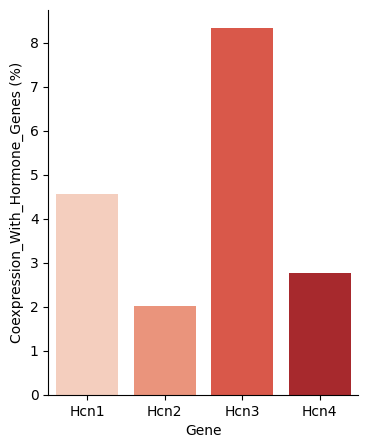

In [635]:
genes_of_interest = ['Hcn1', 'Hcn2', 'Hcn3', 'Hcn4']
hormone_genes = ['Esr1', 'Pgr']
plot_gene_expression(neuron_data, genes_of_interest)
plot_percentage_expressed(neuron_data, genes_of_interest)
coexpression = calculate_coexpression(neuron_data, genes_of_interest, hormone_genes)


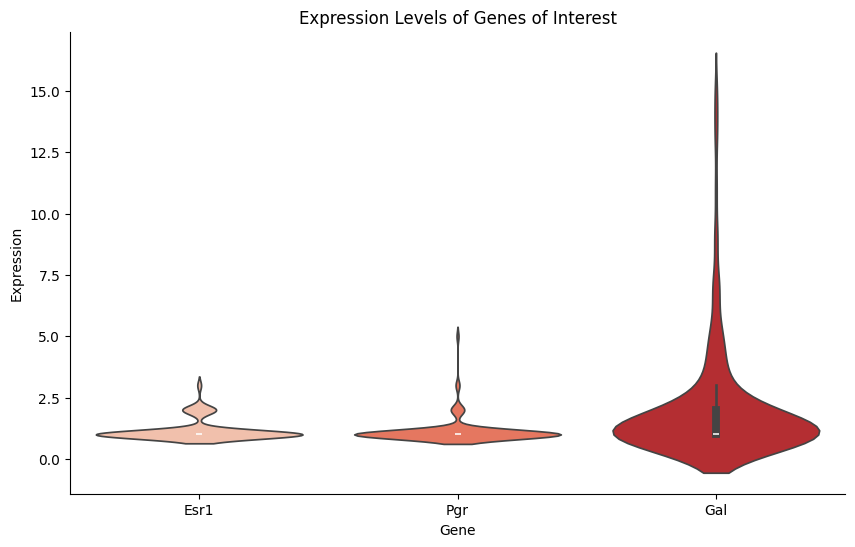

     Percentage
Esr1   0.341351
Pgr    0.614431
Gal    1.003046


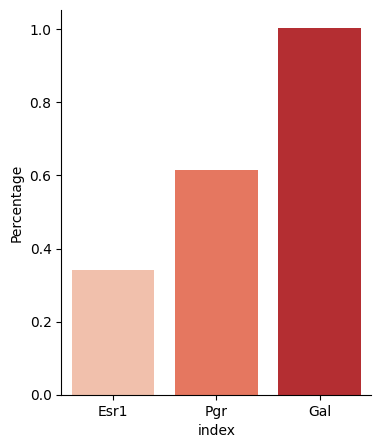

In [636]:
genes_of_interest = ['Esr1', 'Pgr', 'Gal']

plot_gene_expression(neuron_data, genes_of_interest)
plot_percentage_expressed(neuron_data, genes_of_interest)

# MERFISH data anaysis

In [2]:
df = pd.read_feather('merfish.feather')

In [3]:
test = df

In [4]:
test['Npyr'] = test.Npy1r + test.Npy2r
print(test[test.Npyr>0].shape[0]/test.shape[0])

0.6863991562954834


In [6]:
# Percentage of neurons positive for either Y1 or Y2
test_Y = test[((test.Npy1r > 0) | (test.Npy2r > 0))]
percent_Y = test_Y.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are either Y1 or Y2: {percent_Y:.2f}%")

Percentage of neurons that are either Y1 or Y2: 68.64%


In [19]:
# Percentage of neurons positive for Y1 only
test_Y1 = test[((test.Npy1r > 0))]
percent_Y1 = test_Y1.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y1: {percent_Y1:.2f}%")

Percentage of neurons that are Y1: 47.99%


In [18]:
# Percentage of neurons positive for Y2 only
test_Y2 = test[((test.Npy2r > 0))]
percent_Y2 = test_Y2.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y2: {percent_Y2:.2f}%")

Percentage of neurons that are Y2: 50.85%


In [15]:
# Calculate the percentage of neurons positive for both Esr1 and Npy2r
test_est = test[(test.Esr1 > 0) & (test.Npy2r > 0)]
percent_est = test_est.shape[0] / test.shape[0] * 100
print(f"Percentage of npy2r+ neurons that are also esr1+: {percent_est:.2f}%")

# Calculate the percentage of neurons positive for both Pgr and Npy2r
test_pgr = test[(test.Pgr > 0) & (test.Npy2r > 0)]
percent_pgr = test_pgr.shape[0] / test.shape[0] * 100
print(f"Percentage of npy2r+ neurons that are also pgr+: {percent_pgr:.2f}%")

# Combined calculation for either Esr1 or Pgr positive
test_combined = test[((test.Esr1 > 0) | (test.Pgr > 0)) & (test.Npy2r > 0)]
percent_combined = test_combined.shape[0] / test.shape[0] * 100
print(f"Percentage of npy2r+ neurons that are either esr1+ or pgr+: {percent_combined:.2f}%")


Percentage of npy2r+ neurons that are also esr1+: 18.92%
Percentage of npy2r+ neurons that are also pgr+: 25.14%
Percentage of npy2r+ neurons that are either esr1+ or pgr+: 31.10%


In [10]:
test_hr = test[ (test.Esr1 >0) & (test.Pgr >0) & (test.Cell_class.isin(['Inhibitory']))]
# test_hr = test
test_hr = test_hr.iloc[:, 9:].drop(columns = ['Fos']).dropna()
test_hr['Pgr_esr'] = np.log(test_hr.Pgr / test_hr.Esr1)
test_hr['Npyr'] = test_hr.Npy1r + test_hr.Npy2r
test_hr = test_hr[test_hr.Npyr>0]
test_hr['Gabra1_log'] = np.log(test_hr['Gabra1'])

/Users/caom/Documents/negative_parental_switch/.conda/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


/Users/caom/Documents/negative_parental_switch/.conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


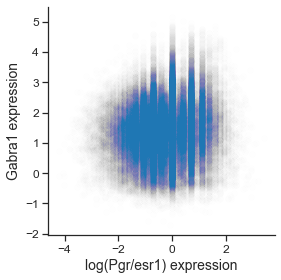

In [11]:
plt.rcParams['figure.figsize'] = 7,5
sns.set_theme(style="ticks")
sns.lmplot(x = 'Pgr_esr', y = 'Gabra1_log' , data = test_hr,scatter_kws={'alpha':0.002, 'color': 'Tab:blue'}, line_kws={'color': 'Tab:blue'},  height=4, aspect=1)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)
plt.xlabel('log(Pgr/esr1) expression', fontsize = 14)
plt.ylabel('Gabra1 expression', fontsize = 14)      
plt.savefig('output_figures/Gabra1_corr.png',dpi = 300, bbox_inches = 'tight')
plt.show()

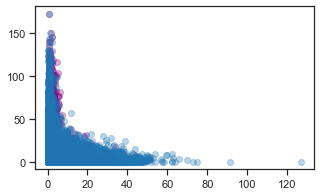

In [8]:
plt.subplots(figsize = (5,3))
plt.scatter(test_hr.Pgr, test_hr.Gabra1 , color = 'purple', alpha = 0.3)
plt.scatter(test_hr.Esr1, test_hr.Gabra1, color = 'Tab:blue', alpha = 0.3)
plt.show()

In [9]:
corr =test_hr.corr().Pgr_esr
display(corr.sort_values())


Esr1         -0.560033
Coch         -0.164719
Scg2         -0.156052
Ar           -0.153568
Ntng1        -0.133731
                ...   
Syt2          0.086817
Gabra1_log    0.114396
Gabra1        0.122658
Pgr           0.264186
Pgr_esr       1.000000
Name: Pgr_esr, Length: 163, dtype: float64

In [10]:
corr =test_hr.corr().Esr1
corr.sort_values()

Pgr_esr      -0.560033
Gabra1_log   -0.183004
Gabra1       -0.179996
Ccnd2        -0.121547
Synpr        -0.107370
                ...   
Coch          0.308312
Scg2          0.345111
Ntng1         0.351045
Pgr           0.446096
Esr1          1.000000
Name: Esr1, Length: 163, dtype: float64